<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/Emergent_Criticality_in_the_Riemann_Hypothesis_through_a_Preprocessing_Paradigm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entropy of the raw signal (Raw Z(t)): 6.335
Entropy of the preprocessed signal (Preprocessed Z(t)): 1.564
---
Entropy reduction (H_reduction): 4.771


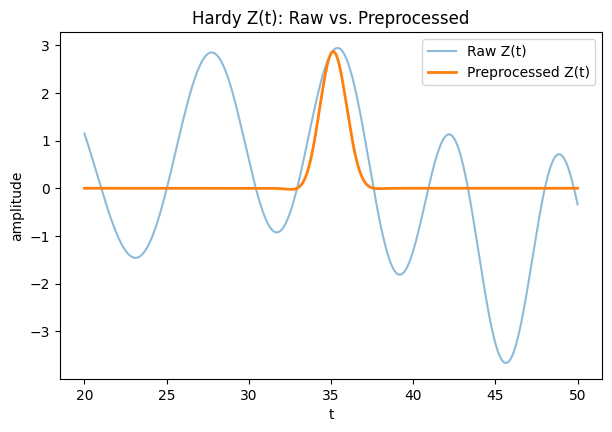

In [ ]:
# Install necessary libraries (if needed)
# !pip install mpmath numpy matplotlib

# 1. Library Imports
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 2. Hardy Z-function Definition and Signal Generation
# Signal interval and preprocessing parameters
T0, T1, dt = 20.0, 50.0, 0.002
sigma_win = 1.0
lowpass_frac = 0.15

# Hardy Z(t)
mp.mp.dps = 60
theta = lambda t: mp.arg(mp.gamma((mp.mpf('1')/2+mp.j*t)/2)) - (t*mp.log(mp.pi))/2
Z = lambda t: mp.re(mp.e**(mp.j*theta(t)) * mp.zeta(0.5+mp.j*t))

# Sample Z(t)
ts = np.arange(T0, T1, dt)
Z_raw = np.array([Z(float(t)) for t in ts], dtype=float)

# Preprocessing: Gaussian window + FFT low-pass filter
win = np.exp(-0.5*((ts - 0.5*(T0+T1))/sigma_win)**2)
Zw = Z_raw * win
F = np.fft.rfft(Zw)
cut = int(lowpass_frac * len(F))
F[cut:] = 0
Z_lp = np.fft.irfft(F, n=len(Zw))


# 3. Entropy Calculation Function Definition
def calculate_entropy(signal, bins=100):
    """
    Calculates the Shannon entropy of a signal.
    - Discretizes the signal into a specified number of bins.
    - Calculates the probability distribution and applies the entropy formula.
    """
    # Set bin boundaries from min/max values of the signal
    min_val, max_val = np.min(signal), np.max(signal)
    if min_val == max_val:  # If signal is constant, entropy is 0
        return 0

    bins = np.linspace(min_val, max_val, bins)
    hist, _ = np.histogram(signal, bins=bins, density=False)

    # Select only non-zero bins to calculate probabilities
    hist_nonzero = hist[hist > 0]
    probabilities = hist_nonzero / np.sum(hist_nonzero)

    # Calculate entropy (using log2)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy


# 4. Entropy Calculation and Result Output
H_raw = calculate_entropy(Z_raw)
H_preprocessed = calculate_entropy(Z_lp)
H_reduction = H_raw - H_preprocessed

print(f"Entropy of the raw signal (Raw Z(t)): {H_raw:.3f}")
print(f"Entropy of the preprocessed signal (Preprocessed Z(t)): {H_preprocessed:.3f}")
print("---")
print(f"Entropy reduction (H_reduction): {H_reduction:.3f}")

# 5. Visualization of Results (Optional)
# Visualize the entropy reduction to intuitively understand it
plt.figure(figsize=(7, 4.5))
plt.plot(ts, Z_raw, alpha=0.5, label="Raw Z(t)")
plt.plot(ts, Z_lp, lw=2.0, label="Preprocessed Z(t)")
plt.title("Hardy Z(t): Raw vs. Preprocessed")
plt.xlabel("t")
plt.ylabel("amplitude")
plt.legend()
plt.show()